In [193]:
from pathlib import Path
import csv
import pandas as pd
from datetime import datetime
from scipy import stats
import matplotlib.pyplot as plt
import numpy as np

path = Path("kc_house_data.csv")

try:
    # Read the file and split it into lines
    lines = path.read_text(encoding='utf-8').splitlines()
    reader = csv.reader(lines)
    header_row = next(reader)  # Read the header row

    data_rows = list(reader)
    print("First row of data", data_rows[0])

except FileNotFoundError:
    print(f"Error: The file {path} does not exist.")

print("\nHeader row", header_row)

dates = [datetime.strptime(date, "%Y%m%d") for date in [ row[1][:8] for row in data_rows ]]
prices = [int(float(price)) for price in [row[2] for row in data_rows]]
bedrooms = [int(row[3]) for row in data_rows]
sqft_living = [ int(row[5]) for row in data_rows]

First row of data ['7129300520', '20141013T000000', '221900', '3', '1', '1180', '5650', '1', '0', '0', '3', '7', '1180', '0', '1955', '0', '98178', '47.5112', '-122.257', '1340', '5650']

Header row ['id', 'date', 'price', 'bedrooms', 'bathrooms', 'sqft_living', 'sqft_lot', 'floors', 'waterfront', 'view', 'condition', 'grade', 'sqft_above', 'sqft_basement', 'yr_built', 'yr_renovated', 'zipcode', 'lat', 'long', 'sqft_living15', 'sqft_lot15']


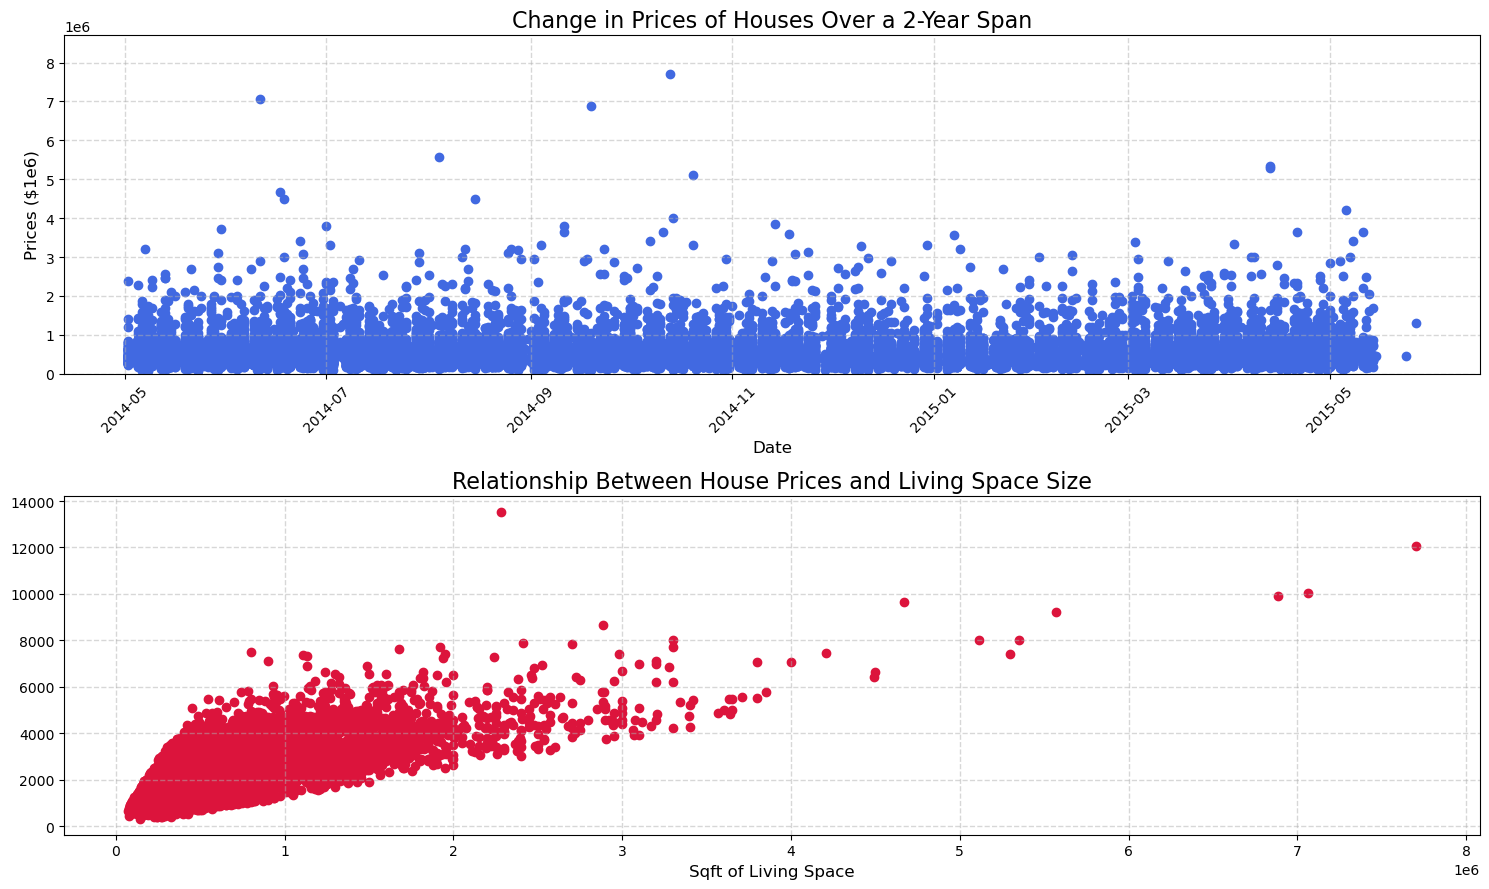

In [19]:
# Create the figure and subplots
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(15, 9)) #Switch the 1 and 2 to alternate between stacked/side by side graphs

# First subplot: Change in Prices of Houses Over a 2-Year Span
ax1.scatter(dates, prices, color='royalblue')
ax1.set_title('Change in Prices of Houses Over a 2-Year Span', fontsize=16)
ax1.set_xlabel('Date', fontsize=12)
ax1.set_ylabel('Prices ($1e6)', fontsize=12)
ax1.grid(visible=True, which='both', linestyle='--', linewidth=1, alpha=0.5)
ax1.tick_params(axis='x', rotation=45)
ax1.set_ylim(bottom=0, top=max(prices) + 1e6)

# Second subplot: Relationship Between House Prices and Living Space Size
ax2.scatter(prices, sqft_living, color='crimson')
ax2.set_title('Relationship Between House Prices and Living Space Size', fontsize=16)
ax2.set_xlabel('Sqft of Living Space', fontsize=12)
ax2.grid(visible=True, which='both', linestyle='--', linewidth=1, alpha=0.5)

# Adjust layout for better spacing
plt.tight_layout()

# Show the combined plot
plt.show()
# Save the figure as a PNG file
fig.savefig('combined_graphs.png', dpi=300, bbox_inches='tight')

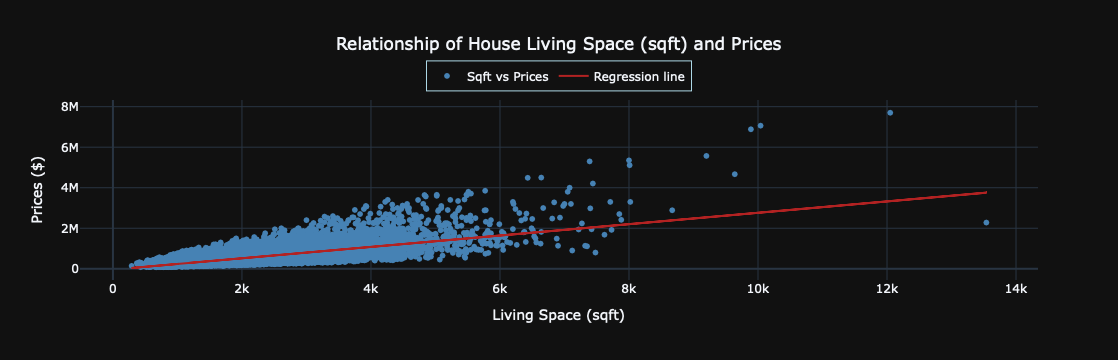

In [454]:
slope, intercept, r, p, std_err = stats.linregress(sqft_living, prices)

def myfunc(x):
    return slope * x + intercept

mymodel = list(map(myfunc, sqft_living))

regression_line = go.Scatter(x = sqft_living, y = mymodel, mode='lines', line = dict(color='firebrick'), name="Regression line")
first_line = go.Scatter(x = sqft_living, y = prices, mode='markers', marker=dict(color='steelblue'), name="Sqft vs Prices")

fig = make_subplots(rows=1, cols=1)
fig.add_trace(first_line, row=1, col=1)
fig.add_trace(regression_line, row=1, col=1)
fig.update_layout(title_text = "Relationship of House Living Space (sqft) and Prices",
                  title_x = 0.5,
                  xaxis_title = "Living Space (sqft)",
                  yaxis_title = "Prices ($)",
                  template = "plotly_dark")

fig.update_layout(
    legend = dict(
        x = 0.5,
        xanchor = "center",
        y = 1.22,
        orientation = "h",
        bordercolor = 'lightblue',
        borderwidth = 1

    )
)

fig.show()
fig.write_image("house_price_analysis.png", width = 1920, height=1080, scale=2)

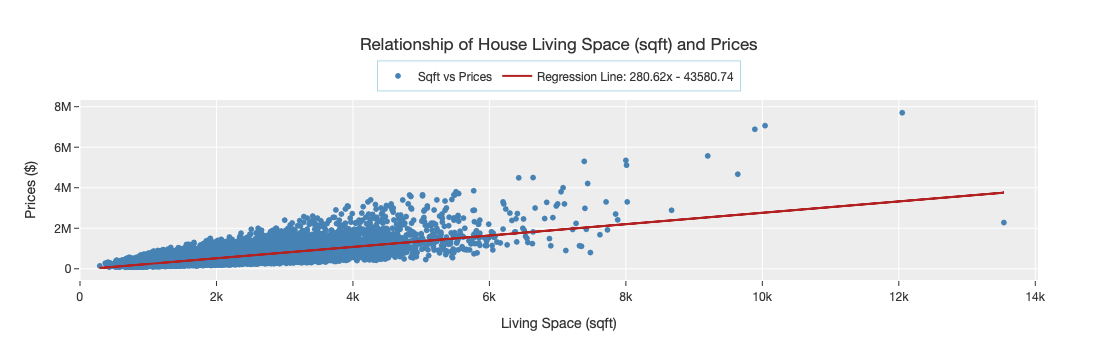

In [574]:
x_array = np.array(sqft_living)[:,np.newaxis]
y = prices

reg = LinearRegression().fit(x_array, y)
reg_score = reg.score(x_array, y)
coef = reg.coef_[0]
intcept = reg.intercept_

y_pred = reg.predict(x_array)

if intcept > 0:
    reg_eq = f"{coef:.2f}x + {intcept:.2f}"
else:
    reg_eq = f"{coef:.2f}x - {abs(intcept):.2f}"

regline = go.Scatter(x = sqft_living, 
                     y = y_pred, 
                     mode='lines',
                     text=[f"Area: {sqft} square feet, Price: ${y}" for sqft, y in zip(sqft_living, y_pred)],
                     hoverinfo = 'text',
                     line = dict(color='firebrick'), 
                     name=f"Regression Line: {reg_eq}")

first_line = go.Scatter(x = sqft_living, 
                        y = prices, 
                        mode ='markers',
                        marker=dict(color='steelblue'), 
                        text=[f"Area: {sqft} square feet, Price: ${price}" for sqft, price in zip(sqft_living, prices)],
                        hoverinfo='text',
                        name="Sqft vs Prices")

fig = make_subplots(rows=1, cols=1)
fig.add_trace(first_line, row=1, col=1)
fig.add_trace(regline, row=1, col=1)
fig.update_layout(title_text = "Relationship of House Living Space (sqft) and Prices",
                  title_x = 0.5,
                  xaxis_title = "Living Space (sqft)",
                  yaxis_title = "Prices ($)",
                  template = "ggplot2")

fig.update_xaxes(range = [0, max(sqft_living) + 500])

fig.update_layout(
    legend = dict(
        x = 0.5,
        xanchor = "center",
        y = 1.22,
        orientation = "h",
        bordercolor = 'lightblue',
        borderwidth = 1
    ),
    font_family = "Helvetica Neue",
)

fig.update_traces(textposition='top center')

fig.show()
fig.write_image("house_price_analysis_v2.png", width = 1920, height=1080, scale=2)